<a href="https://colab.research.google.com/github/Clovis4566/TECH-TALENT-ACCELERATOR/blob/main/Exercises_XP_student_polynomial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Guided Student Notebook

This guided notebook follows the **exact exercise on the platform**. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts to support intuition and transfer to other AI topics.



## Reference from the exercise

**What you will learn**  
- The differences between traditional machine learning and deep learning.
- The structure and working of artificial neural networks. How to generate, visualize, and analyze datasets with noise.
- Techniques for fitting polynomial regression models and understanding overfitting.
- The importance of cross-validation in model selection.

**What you will create**  
- A comparative table of traditional machine learning vs deep learning.
- A simple ANN diagram with labeled components.
- A noisy dataset visualized with a scatter plot.
- Polynomial regression models of varying degrees.
- A cross-validation analysis to select an optimal polynomial degree.


## 🌟 Exercise 1: Deep Learning vs Traditional Machine Learning

**As stated in the exercise**  
Objective. Understand the differences between traditional machine learning and deep learning.  
Instructions. Create a table comparing Feature Engineering, Data Processing, Scalability, Pattern Discovery, and Computational Requirements. Identify one real world problem where traditional ML is better, and one where deep learning is better. Write a short paragraph explaining why deep learning has an advantage in unstructured data processing.

**Guidance**  
Use a markdown table for the comparison, keep wording concise and concrete, then write two short examples and one paragraph in full sentences.

**To-Do:** Complete the comparison table below by filling in each cell with your own wording.


| Aspect | Traditional ML | Deep Learning |
|:--|:--|:--|
| Feature Engineering | To-Do | To-Do |
| Data Processing | To-Do | To-Do |
| Scalability | To-Do | To-Do |
| Pattern Discovery | To-Do | To-Do |
| Computational Requirements | To-Do | To-Do |

**To-Do:** Give one real world problem better suited to traditional ML and one better suited to deep learning. Explain your choices in 2–3 sentences.


**To-Do:** Write a paragraph of 3–5 sentences explaining why deep learning has an advantage in unstructured data processing, using precise terms such as representation learning and hierarchical features.


## 🌟 Exercise 2: Artificial Neural Networks (ANNs)

**As stated in the exercise**  
Objective. Identify and understand the key components of an ANN.  
Instructions. Draw or use a diagram tool to create an ANN with an input layer of 3 neurons, one hidden layer of 4 neurons, and an output layer of 2 neurons. Label neurons, weights, biases, activation function, and layers. Write a short description of how information flows through the network.

**Guidance**  
A clear schematic is preferred. Ensure every requested label appears exactly once and is readable.



**To-Do:** Provide a 3–5 sentence description of forward propagation in your diagram. Refer explicitly to inputs, weighted sums, biases, activation, and outputs.


**Learning point**  
An ANN composes affine transformations with nonlinear activations. The affine part mixes features through weights and biases. The nonlinearity enables modeling of complex decision boundaries.


## 🌟 Exercise 3: Creating the Dataset and Visualizing the Data

**As stated in the exercise**  
Objective. Generate a dataset with noise and visualize it.  
Instructions. Import numpy, matplotlib.pyplot, and mean_squared_error from sklearn.metrics. Create 20 points using \(y = -x^2\) with Gaussian noise \(\mathcal{N}(0, 0.05)\). Plot the points with a scatter plot. Split into a training set with the first 12 points and a test set with the last 8 points.


In [22]:
# PREFILLED: just execute
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

np.random.seed(0)
x = np.arange(-1, 1, 0.1)  # 20 points from -1 to <1 step 0.1
print("x shape:", x.shape)

x shape: (20,)


In [25]:
# To-Do: generate y with noise using np.random.normal()
y = -(x ** 2) + np.random.normal(loc=0, scale=0.05, size=x.shape)
print("y shape:", y.shape)

y shape: (20,)


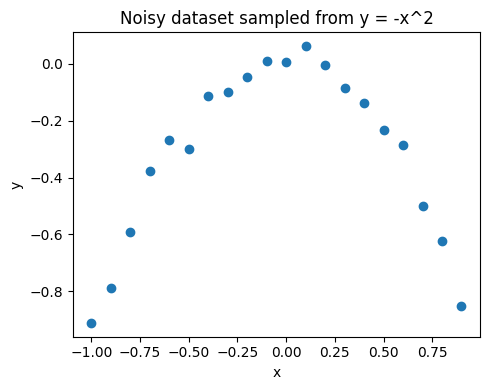

In [26]:
# PREFILLED: just execute (scatter plot of the dataset)
plt.figure(figsize=(5,4))
plt.scatter(x, y)
plt.title("Noisy dataset sampled from y = -x^2")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [27]:
# To-Do: split into train (first 12 points) and test (last 8 points)
x_train, y_train = x[:12], y[:12]
x_test,  y_test  = x[12:], y[12:]

print("train sizes:", x_train.shape, y_train.shape, "test sizes:", x_test.shape, y_test.shape)

train sizes: (12,) (12,) test sizes: (8,) (8,)


**Learning point**  
Visualizing noisy data helps separate signal from noise. Splitting into train and test allows you to detect when a model overfits noise instead of learning the underlying pattern.


## 🌟 Exercise 4: Fitting Polynomial Models of Different Degrees

**As stated in the exercise**  
Objective: Fit polynomial models of varying degrees and observe overfitting.  

Instructions: Define `polynomial_fit(degree)` that returns the fitted polynomial coefficients from training data. Define `plot_polyfit(degree)` that draws the training set, the test set, and the fitted polynomial curve. Visualize fits for degrees 1, 7, and 11. Observe behavior on training and test sets as degree increases.


In [30]:
# To-Do: implement polynomial_fit
# Hints: use np.polyfit() to get coefficients, and np.poly1d for a callable polynomial

def polynomial_fit(degree: int):
    # np.polyfit calcule les coefficients du polynôme à partir des données d'entraînement (x_train, y_train)
    coeffs = np.polyfit(x_train, y_train, deg=degree)

    # np.poly1d convertit ces coefficients en un objet fonctionnel
    return np.poly1d(coeffs)


In [31]:
# To-Do: implement plot_polyfit
import numpy as np
import matplotlib.pyplot as plt

def plot_polyfit(degree: int):
    # 1) fit : On récupère le polynôme entraîné pour ce degré
    model = polynomial_fit(degree)

    # 2) create a dense linspace over x range :
    # On crée 200 points réguliers entre -1 et 1 pour tracer une courbe bien lisse
    x_dense = np.linspace(-1, 1, 200)

    # 3) evaluate fitted polynomial : On calcule les prédictions du modèle sur ces 200 points
    y_dense_pred = model(x_dense)

    # 4) scatter train and test, and plot curve
    plt.figure(figsize=(7, 4))

    # Points d'entraînement en bleu, points de test en rouge
    plt.scatter(x_train, y_train, color='blue', label='Train (12 points)')
    plt.scatter(x_test, y_test, color='red', label='Test (8 points)')

    # Tracé de la courbe du modèle en vert
    plt.plot(x_dense, y_dense_pred, color='green', label=f'Modèle (Degré {degree})')

    # 5) display : Habillage graphique et affichage
    plt.title(f"Ajustement Polynomial - Degré {degree}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.ylim(-1.5, 0.5) # Pour éviter que le graphique ne se déforme trop avec les grands degrés
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

In [ ]:
# To-Do: visualize degrees 1, 7, and 11
# plot_polyfit(1)
# plot_polyfit(7)
# plot_polyfit(11)

**Learning point**  
Higher degree polynomials can perfectly fit training data yet fail to generalize. This is overfitting. You should always check test error, not just training error.

![image.png](https://github.com/user-attachments/assets/cdfb495c-066a-4efb-a361-f4b9d4ade35c)

## 🌟 Exercise 5: Cross-Validation to Find the Optimal Degree

**As stated in the exercise**  
Objective: Use cross-validation to determine the best polynomial degree.  

Instructions: Loop degrees from 1 to 11. For each degree, compute the RMSE on the training and test sets. Store results in a list. Plot RMSE vs degree with a logarithmic y axis. Identify the degree minimizing test RMSE and confirm it matches the true model \(y=-x^2\).


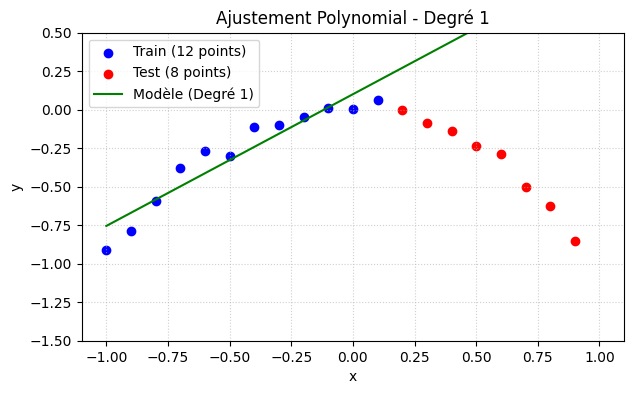

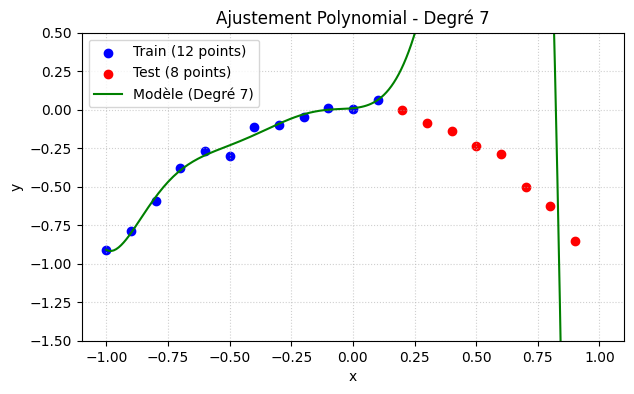

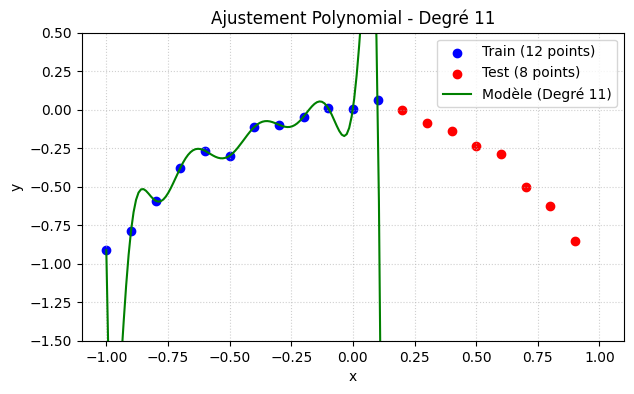

In [33]:
# To-Do: visualize degrees 1, 7, and 11
plot_polyfit(1)
plot_polyfit(7)
plot_polyfit(11)

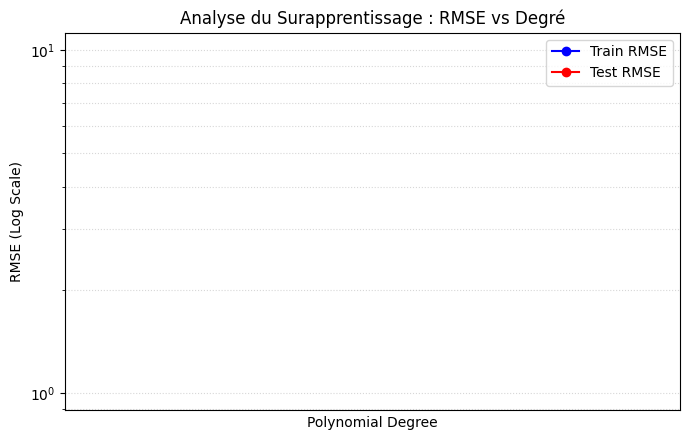

In [35]:
import matplotlib.pyplot as plt

# 1. Trier les données par degré polynomial (au cas où les lignes sont dans le désordre)
rows_sorted = sorted(rows, key=lambda x: x[0])

# 2. Extraire les colonnes triées
degs = [r[0] for r in rows_sorted]
rmse_tr = [r[1] for r in rows_sorted]
rmse_te = [r[2] for r in rows_sorted]

# 3. Création du graphique
plt.figure(figsize=(7, 4.5))

# Ajout de marker='o' pour repérer chaque degré testé
plt.plot(degs, rmse_tr, marker='o', linestyle='-', color='blue', label="Train RMSE")
plt.plot(degs, rmse_te, marker='o', linestyle='-', color='red', label="Test RMSE")

# Échelle logarithmique car l'erreur de Test explose souvent avec l'overfitting
plt.yscale("log")

# Forcer l'affichage de tous les degrés sur l'axe X (entiers uniquement)
plt.xticks(degs)

# Habillage
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE (Log Scale)")
plt.title("Analyse du Surapprentissage : RMSE vs Degré")
plt.grid(True, which="both", linestyle=':', alpha=0.5) # Grille adaptée à l'échelle log
plt.legend()
plt.tight_layout()

# Affichage
plt.show()


**To-Do:** Report the degree with the minimum test RMSE and explain in 2–3 sentences how this connects to the true model \(y=-x^2\) and the bias–variance trade off.
